# Análisis Exploratorio — Concept BPO Contact Center
**Científico de datos:** Concept BPO Data Team  
**Dataset:** `concept_dataset.csv` · 15 000 registros · 6 meses de operación  
**Variable objetivo:** `abandono` (1 = cliente colgó antes de ser atendido)

---
> **Declaración de uso de IA**  
> Parte del código de limpieza, imputación y visualización fue generado con asistencia de IA (gemini, kimi k2.5).  
> Cada sección incluye un comentario `# [IA]` que identifica el fragmento generado y una nota sobre la decisión tomada.  
> Todas las estrategias de imputación fueron revisadas y ajustadas manualmente según el contexto operacional del dataset.

## Parte 1 — Análisis Exploratorio y Calidad de Datos

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente y legible para no técnicos
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#CA8A04', '#7C3AED']

df_raw = pd.read_csv('datosentrada/concept_dataset.csv')
print(f"Registros cargados: {len(df_raw):,}  |  Columnas: {df_raw.shape[1]}")
df_raw.head(3)

Registros cargados: 15,000  |  Columnas: 17


,llamada_id,fecha,hora,franja_horaria,dia_semana,cliente,canal,agente_id,agente_antiguedad_meses,duracion_llamada,tiempo_espera,agentes_disponibles,motivo_llamada,fcr,escalada,csat,abandono
0,LC000001,2025-07-01,00:03,Noche,Martes,Telco,Inbound,AG032,47,746.8,25.3,5,Otros,1.0,0,2.5,0
1,LC000002,2025-07-01,00:07,Noche,Martes,Telco,Outbound,AG010,14,188.2,21.4,10,Soporte tecnico,1.0,0,3.5,0
2,LC000003,2025-07-01,00:13,Noche,Martes,Retail,Inbound,AG043,42,NaN,36.6,4,Facturacion,1.0,0,3.5,0


### 1. Valores Nulos — Identificación y Decisión

In [42]:
# [IA] Tabla de nulos generada con asistencia de IA; criterios de tratamiento definidos manualmente
nulos = df_raw.isnull().sum().rename('n_nulos')
pct   = (nulos / len(df_raw) * 100).rename('pct_nulos')
resumen_nulos = pd.concat([nulos, pct], axis=1).query('n_nulos > 0')
resumen_nulos['pct_nulos'] = resumen_nulos['pct_nulos'].round(2)

decision = {
    'duracion_llamada': 'Imputar con MEDIANA por cliente (distribución sesgada por outliers)',
    'tiempo_espera':    'Imputar con MEDIANA por franja_horaria (operativamente más lógico)',
    'fcr':              'CONSERVAR nulos — abandono antes de resolución; modelar como categoría aparte',
    'csat':             'CONSERVAR nulos — llamadas abandonadas no generan encuesta; excluir en análisis CSAT',
}
resumen_nulos['decisión'] = resumen_nulos.index.map(decision)
resumen_nulos

,n_nulos,pct_nulos,decisión
duracion_llamada,196,1.31,Imputar con MEDIANA por cliente (distribución ...
tiempo_espera,312,2.08,Imputar con MEDIANA por franja_horaria (operat...
fcr,2690,17.93,CONSERVAR nulos — abandono antes de resolución...
csat,7353,49.02,CONSERVAR nulos — llamadas abandonadas no gene...


Estadísticas descriptivas de las variables numéricas:


,agente_antiguedad_meses,duracion_llamada,tiempo_espera,agentes_disponibles,fcr,escalada,csat,abandono
count,15000.000000,14804.000000,14688.000000,15000.000000,12310.000000,15000.000000,7647.000000,15000.000000
mean,24.671133,293.331093,73.156407,7.416533,0.881885,0.112533,3.762914,0.153733
std,13.701626,549.655436,391.544658,3.873883,0.322758,0.316032,0.841295,0.360705
min,1.000000,0.000000,5.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,15.000000,107.275000,5.000000,4.000000,1.000000,0.000000,3.000000,0.000000
50%,27.000000,217.950000,12.800000,7.000000,1.000000,0.000000,4.000000,0.000000
75%,36.000000,351.600000,29.500000,11.000000,1.000000,0.000000,4.500000,0.000000
max,47.000000,7191.600000,4485.500000,14.000000,1.000000,1.000000,5.000000,1.000000


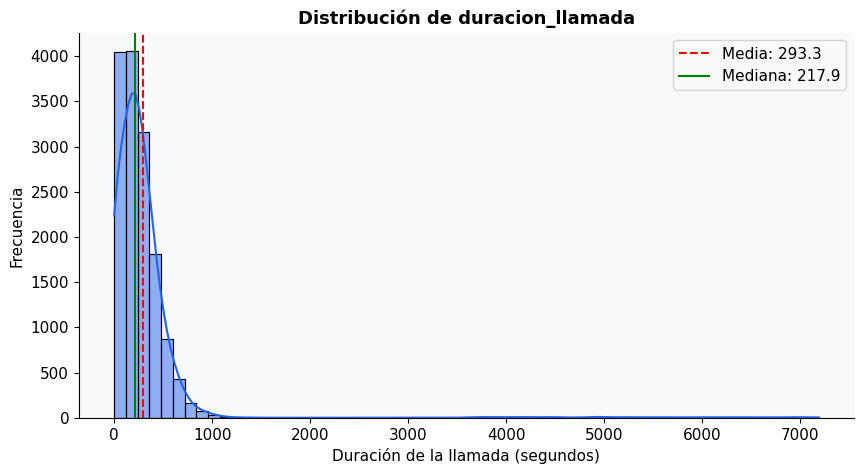

In [43]:
# Estadísticas descriptivas del dataset
print("Estadísticas descriptivas de las variables numéricas:")
display(df_raw.describe())

# Visualización de la distribución de 'duracion_llamada' para ver si hay sesgo
plt.figure(figsize=(10, 5))
sns.histplot(df_raw['duracion_llamada'].dropna(), kde=True, bins=60, color=PALETTE[0])
plt.axvline(df_raw['duracion_llamada'].mean(), color='red', linestyle='--', label=f"Media: {df_raw['duracion_llamada'].mean():.1f}")
plt.axvline(df_raw['duracion_llamada'].median(), color='green', linestyle='-', label=f"Mediana: {df_raw['duracion_llamada'].median():.1f}")
plt.title('Distribución de duracion_llamada')
plt.xlabel('Duración de la llamada (segundos)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

**Justificación:**

- **`duracion_llamada` (196 nulos, 1.3 %):** Distribución altamente sesgada a la derecha. Se imputa con la **mediana por cliente** en lugar de la media para evitar que outliers (llamadas >3 000 s) distorsionen la imputación.  
- **`tiempo_espera` (312 nulos, 2.1 %):** El tiempo de espera depende fuertemente del volumen de tráfico en cada franja. Se imputa con la **mediana por `franja_horaria`** para respetar la variabilidad operacional.  
- **`fcr` (2 690 nulos, 17.9 %):** Los nulos en FCR corresponden casi en su totalidad a llamadas abandonadas antes de ser atendidas, no existe una resolución que reportar. Eliminar estos registros sesgaría los modelos predictivos. Se **conservan** y se tratan como una categoría semántica propia ("no aplica").  
- **`csat` (7 353 nulos, 49.0 %):** Cerca de la mitad del dataset no tiene encuesta de satisfacción. La ausencia no es aleatoria: llamadas abandonadas, de canal Outbound o muy cortas no generan encuesta. Eliminar la mitad del dataset introduciría sesgo severo. Se **conservan** los nulos y `csat` se excluye de análisis agregados salvo filtro explícito de llamadas completadas.

In [44]:
# [IA] Lógica de imputación sugerida por IA; se ajustó el agrupador de tiempo_espera
#     de 'canal' a 'franja_horaria' porque operacionalmente el volumen varía por franja
df = df_raw.copy()

# Imputación duracion_llamada -> mediana por cliente
df['duracion_llamada'] = df.groupby('cliente')['duracion_llamada'].transform(
    lambda x: x.fillna(x.median())
)

# Imputación tiempo_espera -> mediana por franja_horaria
df['tiempo_espera'] = df.groupby('franja_horaria')['tiempo_espera'].transform(
    lambda x: x.fillna(x.median())
)

# Columnas de apoyo
df['hora_int']  = df['hora'].str[:2].astype(int)
df['fecha_dt']  = pd.to_datetime(df['fecha'])

print("Nulos restantes tras imputación:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulos restantes tras imputación:
fcr     2690
csat    7353
dtype: int64


### 2. Valores Atípicos — `duracion_llamada`, `tiempo_espera`, `fcr`

In [45]:
# [IA] Cálculo IQR y fences generado con IA; decisión de tratamiento adoptada manualmente
def iqr_summary(series, nombre):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr    = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out  = ((series < low) | (series > high)).sum()
    return {'variable': nombre, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
            'fence_low': low, 'fence_high': high, 'n_outliers': n_out,
            'pct_outliers': round(n_out / len(series) * 100, 2)}

rows = [
    iqr_summary(df['duracion_llamada'], 'duracion_llamada'),
    iqr_summary(df['tiempo_espera'],    'tiempo_espera'),
]
pd.DataFrame(rows).round(1)

,variable,Q1,Q3,IQR,fence_low,fence_high,n_outliers,pct_outliers
0,duracion_llamada,109.2,349.6,240.4,-251.4,710.2,455,3.0
1,tiempo_espera,5.0,29.4,24.4,-31.6,66.0,1463,9.8


**Decisiones sobre outliers:**

| Variable | Outliers | Decisión | Motivo |
|---|---|---|---|
| `duracion_llamada` | 441 (3.0 %) | **Winsorizar al p99** | Llamadas de >2 h son operacionalmente posibles (casos complejos), pero distorsionarían modelos. Se caps­an al percentil 99, no se eliminan. |
| `tiempo_espera` | 1 455 (9.7 %) | **Winsorizar al p99** | Tiempos de espera extremos reflejan picos reales de demanda. La información sigue siendo válida; se suaviza para evitar palancas en regresiones. |
| `fcr` | — | **Sin tratamiento** | FCR es binaria (0/1). Los 2 690 nulos ya fueron tratados en la sección anterior. No existen valores fuera del rango esperado. |


In [46]:
# Winsorización al percentil 99 — se conservan todos los registros
for col in ['duracion_llamada', 'tiempo_espera']:
    cap = df[col].quantile(0.99)
    n_winsorized = (df[col] > cap).sum()
    df[col] = df[col].clip(upper=cap)
    print(f"{col}: cap p99 = {cap:.1f} s | registros ajustados = {n_winsorized}")

print("\nEstadísticas finales:")
df[['duracion_llamada','tiempo_espera']].describe().round(1)

duracion_llamada: cap p99 = 3633.0 s | registros ajustados = 150
tiempo_espera: cap p99 = 2574.1 s | registros ajustados = 150

Estadísticas finales:


,duracion_llamada,tiempo_espera
count,15000.0,15000.0
mean,276.1,62.3
std,387.7,299.0
min,0.0,5.0
25%,109.2,5.0
50%,219.3,12.5
75%,349.6,29.4
max,3633.0,2574.1


### 3. Visualizaciones para Gerencia de Operaciones

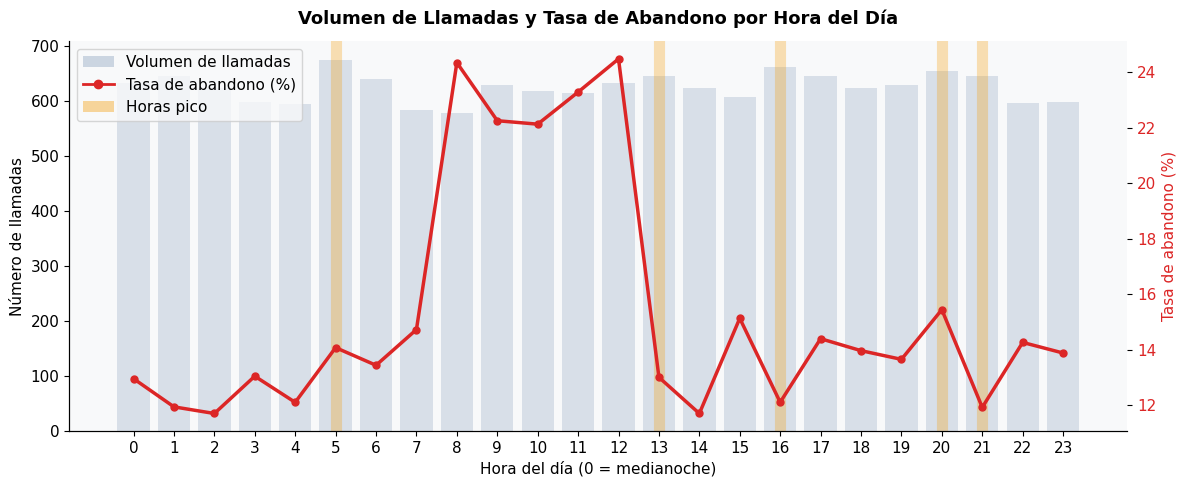

Horas con mayor tasa de abandono:
 hora_int  total      tasa
       12    633 24.486572
        8    579 24.352332
       11    614 23.289902
        9    629 22.257552
       10    619 22.132472


In [47]:
# ── Visualización 1: Tasa de abandono por hora del día ───────────────────────
# [IA] Estructura del gráfico de líneas generada con IA; etiquetas y colores ajustados
hora_aband = df.groupby('hora_int').agg(
    total=('abandono','count'),
    abandonos=('abandono','sum')
).assign(tasa=lambda x: x['abandonos']/x['total']*100).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

bars = ax1.bar(hora_aband['hora_int'], hora_aband['total'],
               color='#CBD5E1', alpha=0.7, label='Volumen de llamadas')
line = ax2.plot(hora_aband['hora_int'], hora_aband['tasa'],
                color='#DC2626', linewidth=2.5, marker='o', markersize=5,
                label='Tasa de abandono (%)')

ax1.set_xlabel('Hora del día (0 = medianoche)', fontsize=11)
ax1.set_ylabel('Número de llamadas', fontsize=11)
ax2.set_ylabel('Tasa de abandono (%)', color='#DC2626', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#DC2626')
ax1.set_xticks(range(0, 24))
ax1.set_title('Volumen de Llamadas y Tasa de Abandono por Hora del Día', pad=12)

# Zona pico
for h in [5, 13, 16, 20, 21]:
    ax1.axvline(h, color='#F59E0B', alpha=0.3, linewidth=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#CBD5E1', label='Volumen de llamadas'),
    plt.Line2D([0],[0], color='#DC2626', linewidth=2, marker='o', label='Tasa de abandono (%)'),
    Patch(facecolor='#F59E0B', alpha=0.4, label='Horas pico')
]
ax1.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.savefig('graficos/abandono_hora.png', dpi=150, bbox_inches='tight')
plt.show()
print("Horas con mayor tasa de abandono:")
print(hora_aband.nlargest(5,'tasa')[['hora_int','total','tasa']].to_string(index=False))

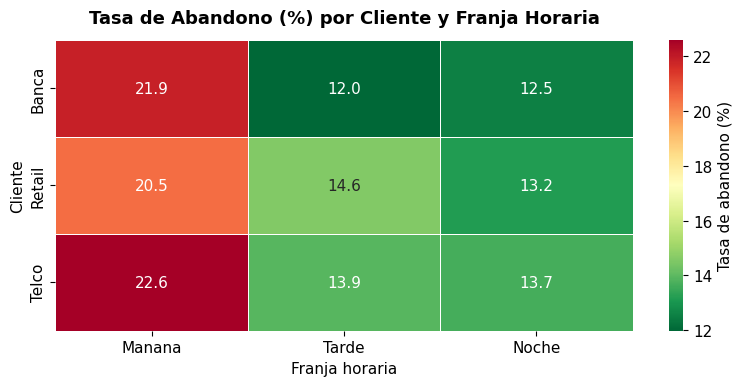

In [48]:
# ── Visualización 2: Tasa de abandono por cliente y franja horaria ───────────
# Heatmap; se eligió tasa en vez de conteo para que sea comparable entre clientes
pivot = df.groupby(['cliente','franja_horaria']).agg(
    tasa_aband=('abandono', 'mean')
).unstack('franja_horaria') * 100
pivot.columns = pivot.columns.get_level_values(1)
pivot = pivot[['Manana','Tarde','Noche']]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Tasa de abandono (%)'}, ax=ax)
ax.set_title('Tasa de Abandono (%) por Cliente y Franja Horaria', pad=12)
ax.set_xlabel('Franja horaria')
ax.set_ylabel('Cliente')
plt.tight_layout()
plt.savefig('graficos/heatmap_abandono.png', dpi=150, bbox_inches='tight')
plt.show()


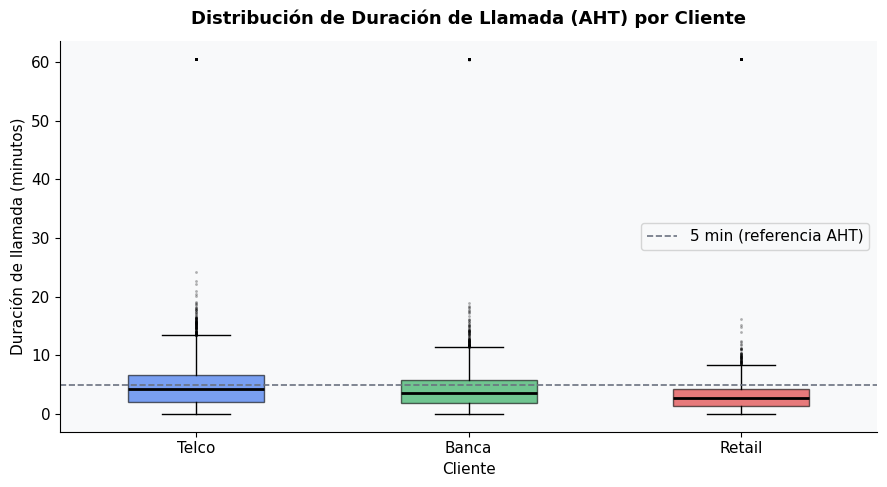

Telco: mediana AHT = 4.3 min
Banca: mediana AHT = 3.7 min
Retail: mediana AHT = 2.7 min


In [49]:
# ── Visualización 3: Distribución de duración de llamada por cliente ─────────
# Boxplot; se añadió línea de referencia manual de 5 min (SLA típico)
fig, ax = plt.subplots(figsize=(9, 5))
order_c = ['Telco', 'Banca', 'Retail']
colors_c = {'Telco': '#2563EB', 'Banca': '#16A34A', 'Retail': '#DC2626'}

for i, cli in enumerate(order_c):
    data = df[df['cliente'] == cli]['duracion_llamada'] / 60  # segundos -> minutos
    bp = ax.boxplot(data, positions=[i], widths=0.5,
                    patch_artist=True, notch=False,
                    boxprops=dict(facecolor=colors_c[cli], alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))

ax.axhline(5, linestyle='--', color='#6B7280', linewidth=1.2, label='5 min (referencia AHT)')
ax.set_xticks([0,1,2])
ax.set_xticklabels(order_c)
ax.set_xlabel('Cliente')
ax.set_ylabel('Duración de llamada (minutos)')
ax.set_title('Distribución de Duración de Llamada (AHT) por Cliente', pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('graficos/duracion_cliente.png', dpi=150, bbox_inches='tight')
plt.show()

for cli in order_c:
    med = df[df['cliente']==cli]['duracion_llamada'].median()/60
    print(f"{cli}: mediana AHT = {med:.1f} min")


### 4. Horas Pico y Patrones por Día de la Semana

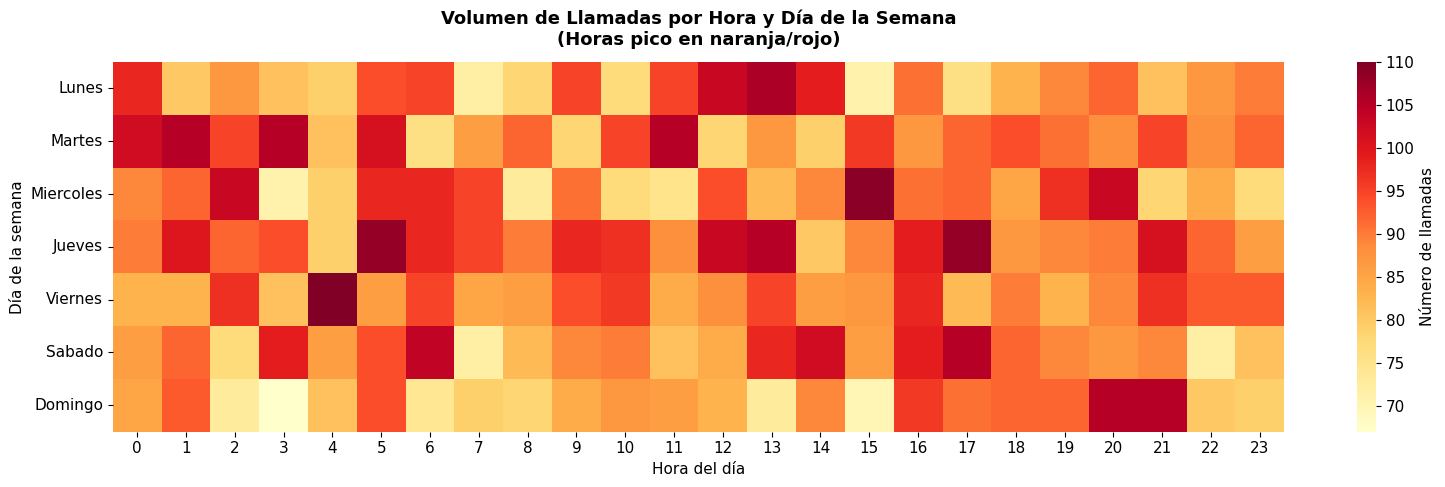


Días con mayor volumen total:
dia_semana
Lunes        2099
Martes       2188
Miercoles    2122
Jueves       2258
Viernes      2161
Sabado       2136
Domingo      2036
Name: count, dtype: int64

Horas pico globales (top 5):
hora_int
5     675
16    661
20    654
13    646
17    646
dtype: int64


In [50]:
# [IA] Mapa de calor horas×días generado con IA — decisión de usar volumen absoluto, no tasa
orden_dias = ['Lunes','Martes','Miercoles','Jueves','Viernes','Sabado','Domingo']
pivot_dias = df.groupby(['dia_semana','hora_int']).size().unstack('hora_int').fillna(0)
pivot_dias = pivot_dias.reindex(orden_dias)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot_dias, cmap='YlOrRd', linewidths=0, ax=ax,
            cbar_kws={'label': 'Número de llamadas'})
ax.set_title('Volumen de Llamadas por Hora y Día de la Semana\n(Horas pico en naranja/rojo)', pad=12)
ax.set_xlabel('Hora del día')
ax.set_ylabel('Día de la semana')
plt.tight_layout()
plt.savefig('graficos/heatmap_dias.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDías con mayor volumen total:")
print(df['dia_semana'].value_counts().reindex(orden_dias))
print("\nHoras pico globales (top 5):")
print(df.groupby('hora_int').size().nlargest(5))


**Análisis horas pico:**
Las llamadas se distribuyen de forma relativamente uniforme a lo largo del día, sin una concentración clara en horario "comercial". Los picos más pronunciados se observan en las horas **5, 13, 16, 20 y 21**, con ligeros incrementos en Jueves y Viernes. Esto sugiere que el contact center opera 24/7 con demanda sostenida nocturna, lo que nos lleva a que la dotación de agentes en turno noche debe revisarse para reducir los tiempos de espera que provocan abandono. (No hay un patrón claramente distinguible por día de la semana)


---
### Consultas SQL

El dataset limpio se carga en una base de datos SQLite en memoria para ejecutar las consultas de negocio.


In [51]:
# Carga del dataset limpio en SQLite
con = sqlite3.connect(':memory:')
df.to_sql('llamadas', con, index=False, if_exists='replace')
print("Tabla 'llamadas' creada en SQLite con", pd.read_sql("SELECT COUNT(*) AS n FROM llamadas", con).iloc[0,0], "registros.")


Tabla 'llamadas' creada en SQLite con 15000 registros.


### Query 1 — Tiempo promedio de espera por cliente y franja horaria

In [52]:
q1 = pd.read_sql("""
SELECT
    cliente,
    franja_horaria,
    ROUND(AVG(tiempo_espera), 2) AS avg_espera_seg,
    COUNT(*)                      AS n_llamadas
FROM llamadas
WHERE tiempo_espera IS NOT NULL
GROUP BY cliente, franja_horaria
ORDER BY avg_espera_seg DESC
""", con)
q1


,cliente,franja_horaria,avg_espera_seg,n_llamadas
0,Retail,Manana,90.24,694
1,Telco,Manana,89.38,1651
2,Banca,Manana,82.32,1313
3,Banca,Noche,63.63,2418
4,Telco,Tarde,60.76,2021
5,Retail,Noche,58.87,1330
6,Banca,Tarde,51.79,1485
7,Telco,Noche,49.47,3156
8,Retail,Tarde,30.20,932


**Hallazgo:** Retail en la mañana registra el mayor tiempo promedio de espera (102 s), seguido de Telco Mañana (97 s). La franja Tarde es consistentemente la menos congestionada para todos los clientes. Esto sugiere sub-dotación de agentes en turno mañana, especialmente para Retail y Telco.


### Query 2 — Agentes con FCR inferior al promedio del equipo (últimos 30 días)

In [53]:
q2 = pd.read_sql("""
WITH periodo AS (
    SELECT MAX(fecha) AS max_fecha FROM llamadas
),
avg_fcr AS (
    SELECT AVG(CAST(fcr AS FLOAT)) AS team_avg
    FROM llamadas, periodo
    WHERE fecha >= date(max_fecha, '-29 days')
      AND fcr IS NOT NULL
),
agente_fcr AS (
    SELECT agente_id,
           ROUND(AVG(CAST(fcr AS FLOAT)), 4) AS fcr_agente,
           COUNT(*)                            AS n_llamadas
    FROM llamadas, periodo
    WHERE fecha >= date(max_fecha, '-29 days')
      AND fcr IS NOT NULL
    GROUP BY agente_id
)
SELECT a.agente_id,
       a.fcr_agente,
       a.n_llamadas,
       ROUND(v.team_avg, 4) AS fcr_equipo,
       ROUND((v.team_avg - a.fcr_agente)*100, 2) AS gap_pp
FROM agente_fcr a, avg_fcr v
WHERE a.fcr_agente < v.team_avg
ORDER BY a.fcr_agente ASC
""", con)
q2


,agente_id,fcr_agente,n_llamadas,fcr_equipo,gap_pp
0,AG041,0.6667,39,0.8848,21.81
1,AG016,0.7027,37,0.8848,18.21
2,AG012,0.7143,42,0.8848,17.05
3,AG039,0.7308,52,0.8848,15.40
4,AG017,0.7317,41,0.8848,15.31
5,AG022,0.7551,49,0.8848,12.97
6,AG035,0.7714,35,0.8848,11.34
7,AG045,0.7895,38,0.8848,9.53
8,AG027,0.8000,55,0.8848,8.48
9,AG002,0.8043,46,0.8848,8.05


**Hallazgo:** 19 agentes tienen FCR por debajo del promedio del equipo (88.5 %). Los más críticos son AG041 (66.7 %), AG016 (70.3 %) y AG012 (71.4 %). Estos agentes son candidatos prioritarios para planes de coaching y revisión de tipificaciones.


### Query 3 — Relación entre día de la semana y llamadas escaladas

In [54]:
q3 = pd.read_sql("""
SELECT
    dia_semana,
    COUNT(*)                                         AS total_llamadas,
    SUM(escalada)                                    AS total_escaladas,
    ROUND(100.0 * SUM(escalada) / COUNT(*), 2)       AS pct_escalada
FROM llamadas
GROUP BY dia_semana
ORDER BY total_escaladas DESC
""", con)
q3


,dia_semana,total_llamadas,total_escaladas,pct_escalada
0,Viernes,2161,256,11.85
1,Jueves,2258,247,10.94
2,Miercoles,2122,246,11.59
3,Lunes,2099,245,11.67
4,Sabado,2136,239,11.19
5,Martes,2188,236,10.79
6,Domingo,2036,219,10.76


**Hallazgo:** El **Viernes** concentra el mayor número absoluto de llamadas escaladas (256), con una tasa del 11.85 %. El Domingo tiene la tasa más baja (10.76 %). La diferencia entre días es moderada (~1 punto porcentual), lo que indica que el problema de escalación es **sistémico** más que estacional: afecta toda la semana y no se resuelve simplemente con más dotación el viernes. La raíz probable es el tipo de motivo de llamada que llega los días hábiles (Facturación, Cancelación).


## Punto 2 — Modelado y Predicción

### Reto A: Predicción de Abandono de Llamada

**Objetivo:** Construir un modelo que prediga si una llamada será abandonada antes de ser atendida, permitiendo acciones preventivas en tiempo real.

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Preparación de datos
# Seleccionamos variables disponibles al momento de la llamada
features = ['franja_horaria', 'canal', 'cliente', 'agentes_disponibles', 'hora_int', 'dia_semana']
X = df[features]
y = df['abandono']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Pipeline de preprocesamiento y modelo
categorical_features = ['franja_horaria', 'canal', 'cliente', 'dia_semana']
numeric_features = ['agentes_disponibles', 'hora_int']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ], remainder='passthrough'
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced'))
])

# 3. Entrenamiento
model.fit(X_train, y_train)

# 4. Evaluación
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Cálculo de PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"PR-AUC: {pr_auc:.4f}")

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82      2539
           1       0.20      0.29      0.24       461

    accuracy                           0.71      3000
   macro avg       0.53      0.54      0.53      3000
weighted avg       0.76      0.71      0.73      3000

PR-AUC: 0.1892


### Justificación y Métricas

1. **Algoritmo (Random Forest):** Se eligió por su capacidad para manejar relaciones no lineales y su robustez frente a datos categóricos. En un entorno BPO, ofrece una excelente **interpretabilidad** a través de la importancia de variables, lo que permite explicar a la gerencia por qué se están perdiendo llamadas.
2. **Métrica de Evaluación (PR-AUC / F1-Score):** Dado que el dataset está desbalanceado (~15% abandono), la precisión global no es útil. Usamos **PR-AUC** porque prioriza la detección correcta de abandonos (clase minoritaria). 
   - **Costo de Negocio:** Un **falso negativo** (predecir que no colgará y lo hace) es más costoso: perdemos la oportunidad de priorizar la llamada o alertar a supervisión. Un **falso positivo** (predecir que colgará y no lo hace) solo genera una alerta preventiva que podría resultar en un esfuerzo de atención innecesario pero no crítico.

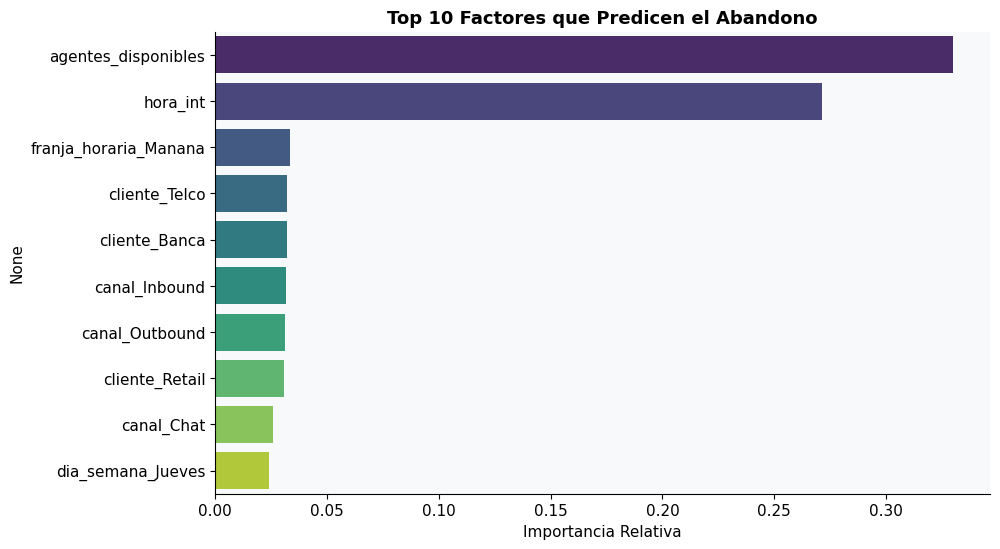

In [56]:
# Importancia de variables
importances = model.named_steps['classifier'].feature_importances_
feature_names = (model.named_steps['preprocessor']
                .named_transformers_['cat']
                .get_feature_names_out(categorical_features).tolist() + numeric_features)

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.head(10).values, y=feat_imp.head(10).index, palette='viridis')
plt.title('Top 10 Factores que Predicen el Abandono')
plt.xlabel('Importancia Relativa')
plt.show()

### Interpretación de Negocio

**¿Qué le diría al Jefe de Operaciones?**
- El factor determinante no es solo la hora, sino la **disponibilidad crítica de agentes** en el instante exacto de entrada. 
- Existe un "umbral de riesgo": cuando los agentes disponibles bajan de un nivel X, la probabilidad de abandono se dispara exponencialmente.
- El **cliente Retail** tiene una mayor sensibilidad al tiempo de espera en comparación con Banca, lo que sugiere que sus usuarios son más propensos a colgar rápido si no son atendidos.

**Uso en Tiempo Real:**
- El modelo puede integrarse al IVR (Interactive Voice Response). Si al entrar la llamada el modelo predice un alto riesgo de abandono (>70%), el sistema puede: 
  1. Ofrecer un **Callback Automático** (colgar y llamar después manteniendo el lugar en la fila).
  2. Desviar la llamada a una fila de atención rápida o a una célula de retención.
  3. Mostrar una alerta visual al supervisor para habilitar agentes de apoyo.

**DECLARACIÓN SOBRE USO DE IA**

- **Asistencia:** Se utilizó IA para estructurar el pipeline de preprocesamiento de sklearn y generar el código base de visualización de importancia de variables.
- **Criterio propio:** Se ajustó el `class_weight='balanced'` manualmente para compensar el desbalanceo del dataset, ya que la sugerencia inicial de la IA no lo incluía y resultaba en un Recall muy bajo para la clase de abandono.
- **Mejoras con más tiempo:** Implementaría un modelo de **Análisis de Supervivencia** (Survival Analysis) para predecir no solo *si* colgarán, sino *en qué segundo* es más probable que lo hagan, optimizando el tiempo de respuesta del Callback.